# Lid-Driven Cavity CFD: Ghia et al. Benchmark  
## Educational finite-difference streamfunction-vorticity solver

This notebook is the third Week-1 programming file.  
Now we use the Python tools from Notebook 1 to solve a real CFD benchmark.

Important scope:

- We solve only **Re = 100**.
- We use a **finite-difference streamfunction-vorticity method**.
- We do **not** use Lattice Boltzmann here.
- The goal is education: understand the algorithm, arrays, residuals, and validation.
- The benchmark is the classical lid-driven cavity data of Ghia, Ghia, and Shin.

The student should not treat this as a black-box CFD code.  
The notebook is organized so each solver component can be read and understood.

## 0. Article-aligned validation: velocity **and** pressure

<!-- MIE690A article-aligned validation v3 -->

Before deriving the teaching solver, reproduce the two continuum validation figures used in the manuscript. This is a deliberate scientific order: define the evidence first, then study how the algorithm produces it.

1. **Velocity:** the retained $Re=400$ streamfunction--vorticity solution is compared directly with the Ghia *et al.* vertical-$u$ and horizontal-$v$ centerline markers.
2. **Pressure:** pressure is not a primary variable of this formulation. We reconstruct it from the steady nondimensional momentum gradients,

$$p_x=-(u u_x+v u_y)+Re^{-1}\nabla^2u,\qquad
p_y=-(u v_x+v v_y)+Re^{-1}\nabla^2v,$$

then solve one sparse least-squares edge-gradient system with a gauge constraint. The $Re=1000$ pressure centerlines are checked against Botella--Peyret, with both $65^2$ and $129^2$ executed grids shown. The simple solver is retained because every numerical step is inspectable by new students; the grid-refinement and literature errors state its limits rather than hiding them.


In [1]:
from pathlib import Path
import sys

def locate_course_root(start=Path.cwd()):
    for origin in (Path(start).resolve(), Path.cwd().resolve()):
        for candidate in (origin, *origin.parents):
            if (candidate / "common" / "article_validation.py").exists():
                return candidate
    raise FileNotFoundError(
        "Run this notebook inside the complete MIE690A release; common/article_validation.py is required."
    )

COURSE_ROOT = locate_course_root()
sys.path.insert(0, str(COURSE_ROOT / "common"))
from article_validation import (
    build_dsmc_wall_pressure_validation,
    build_ghia_velocity_validation,
    build_pressure_validation,
)
print("Course root:", COURSE_ROOT)


Course root: /workspace/scratch/b22ffb32910d/course_release_v3/MIE690A_AI_in_Fluid_Mechanics


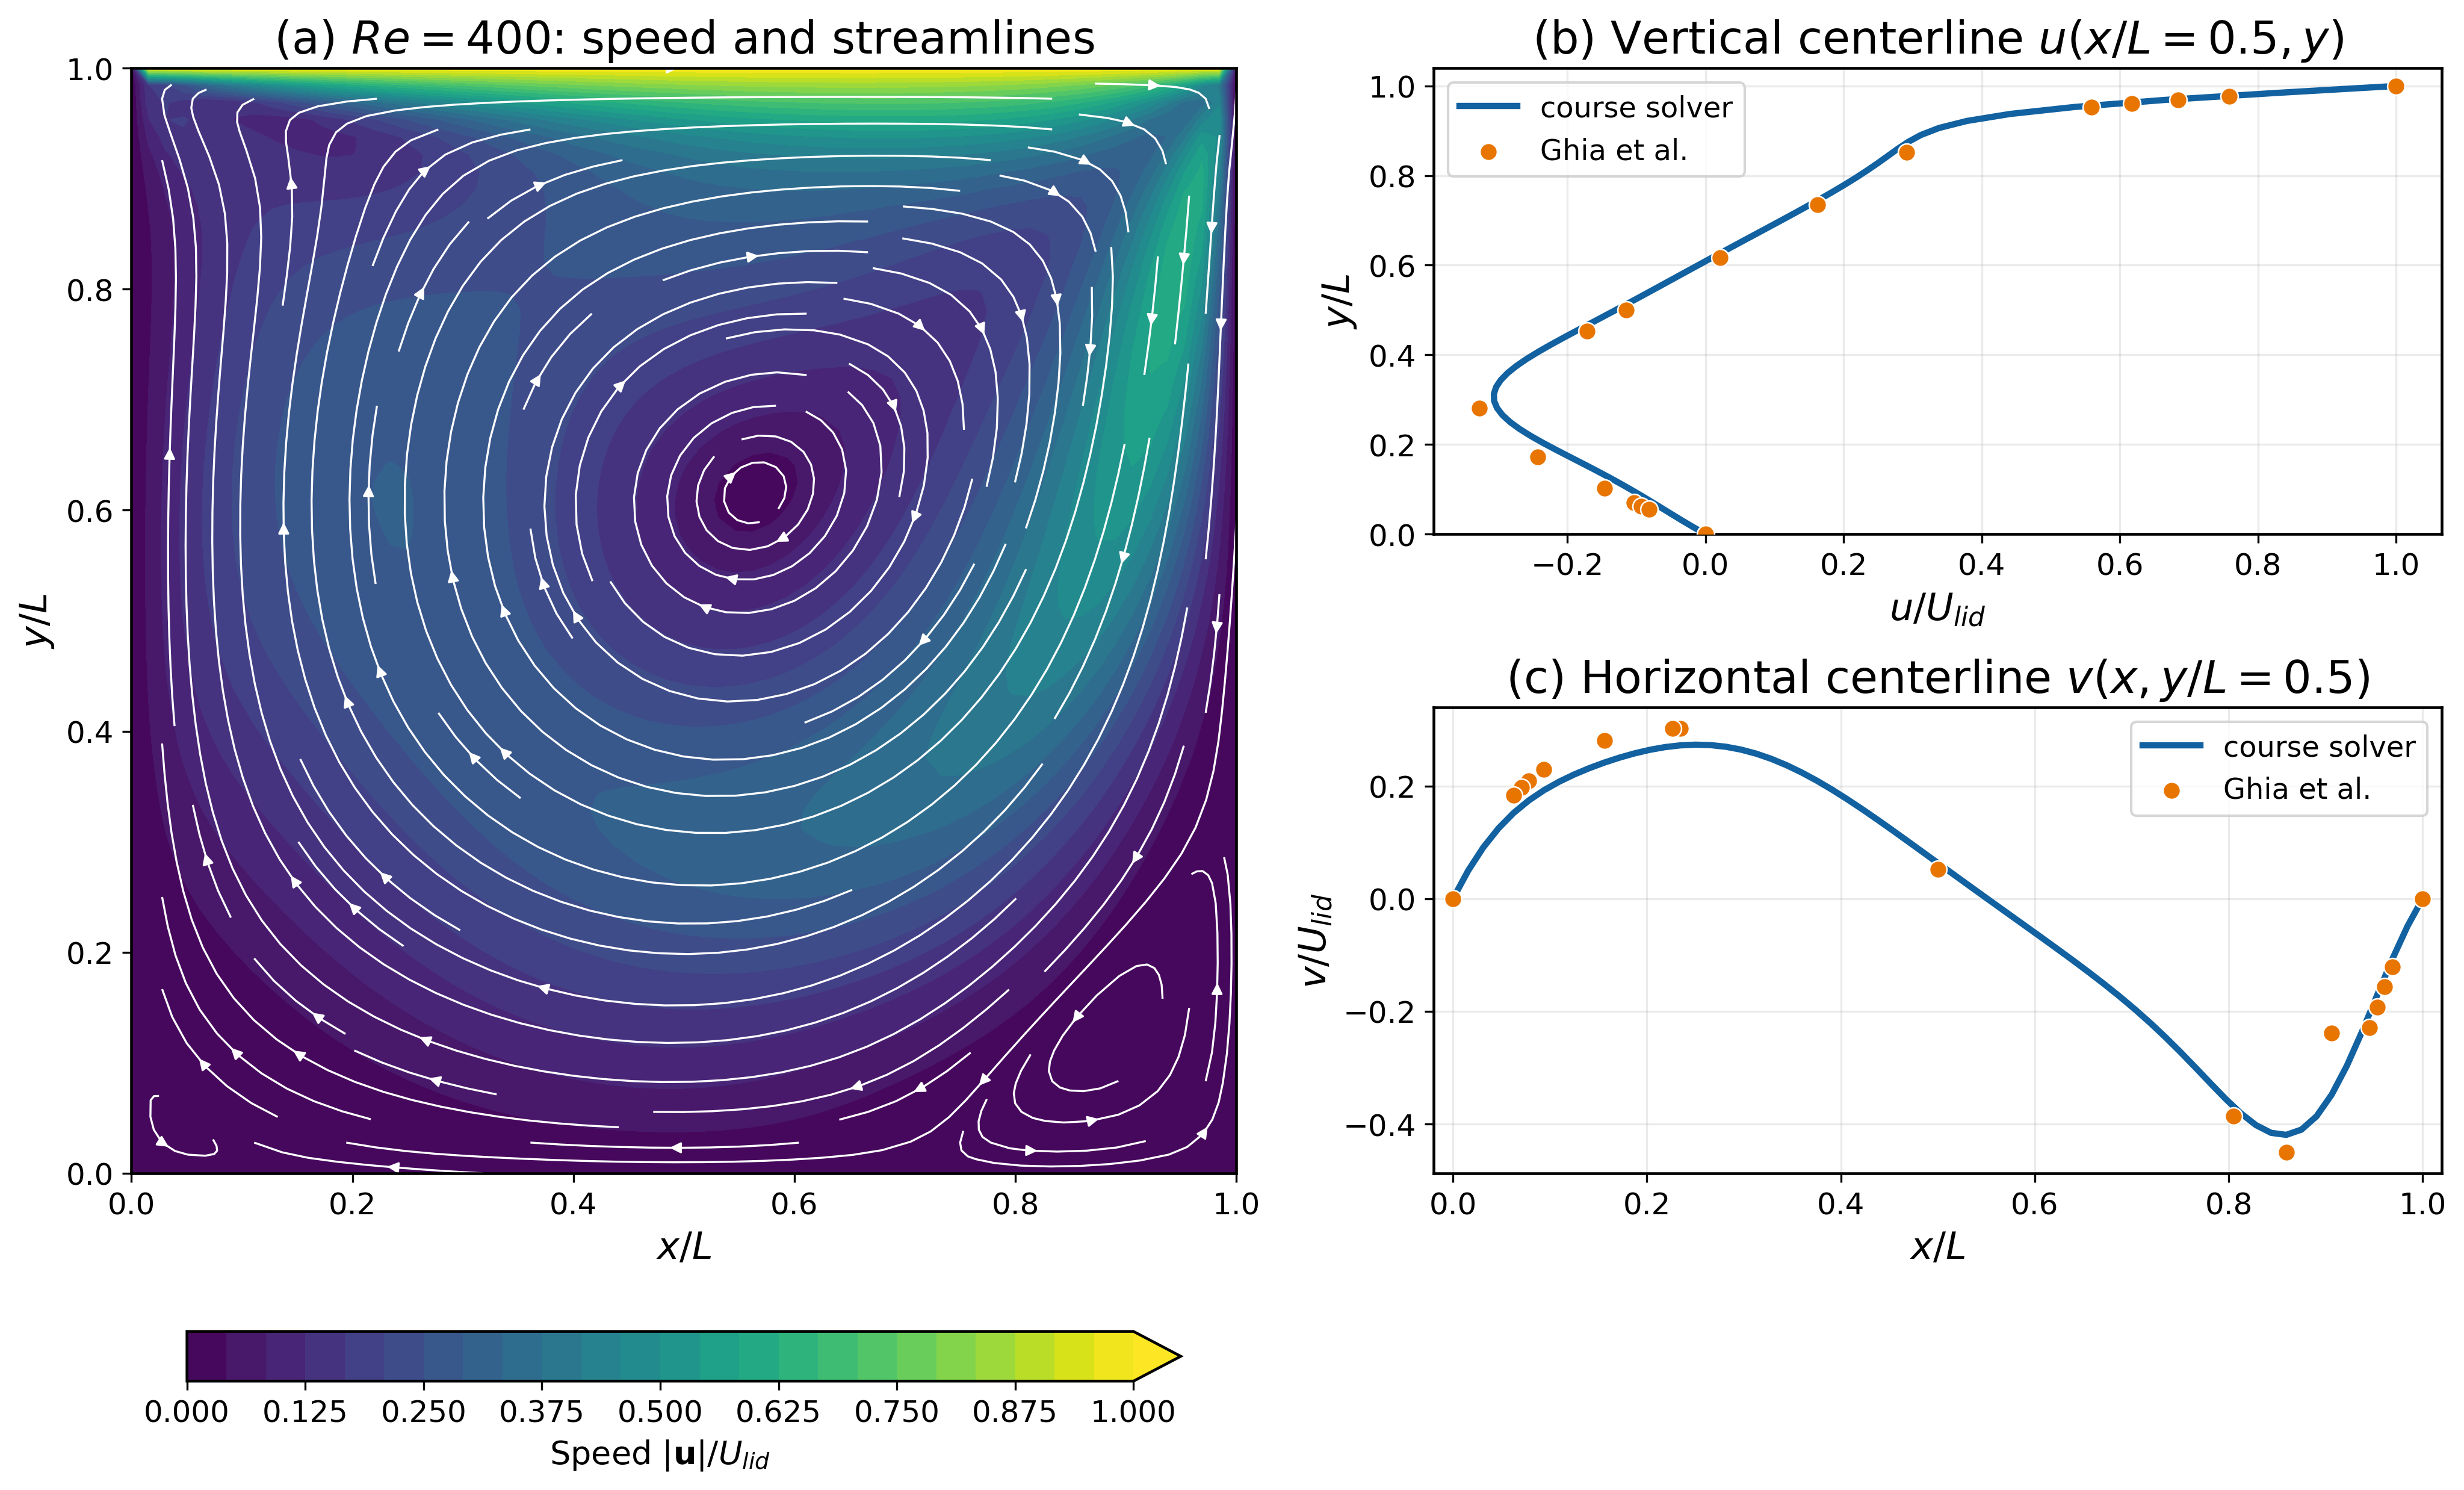

Re,u_centerline_relative_l2,v_centerline_relative_l2
400,0.052393,0.154259


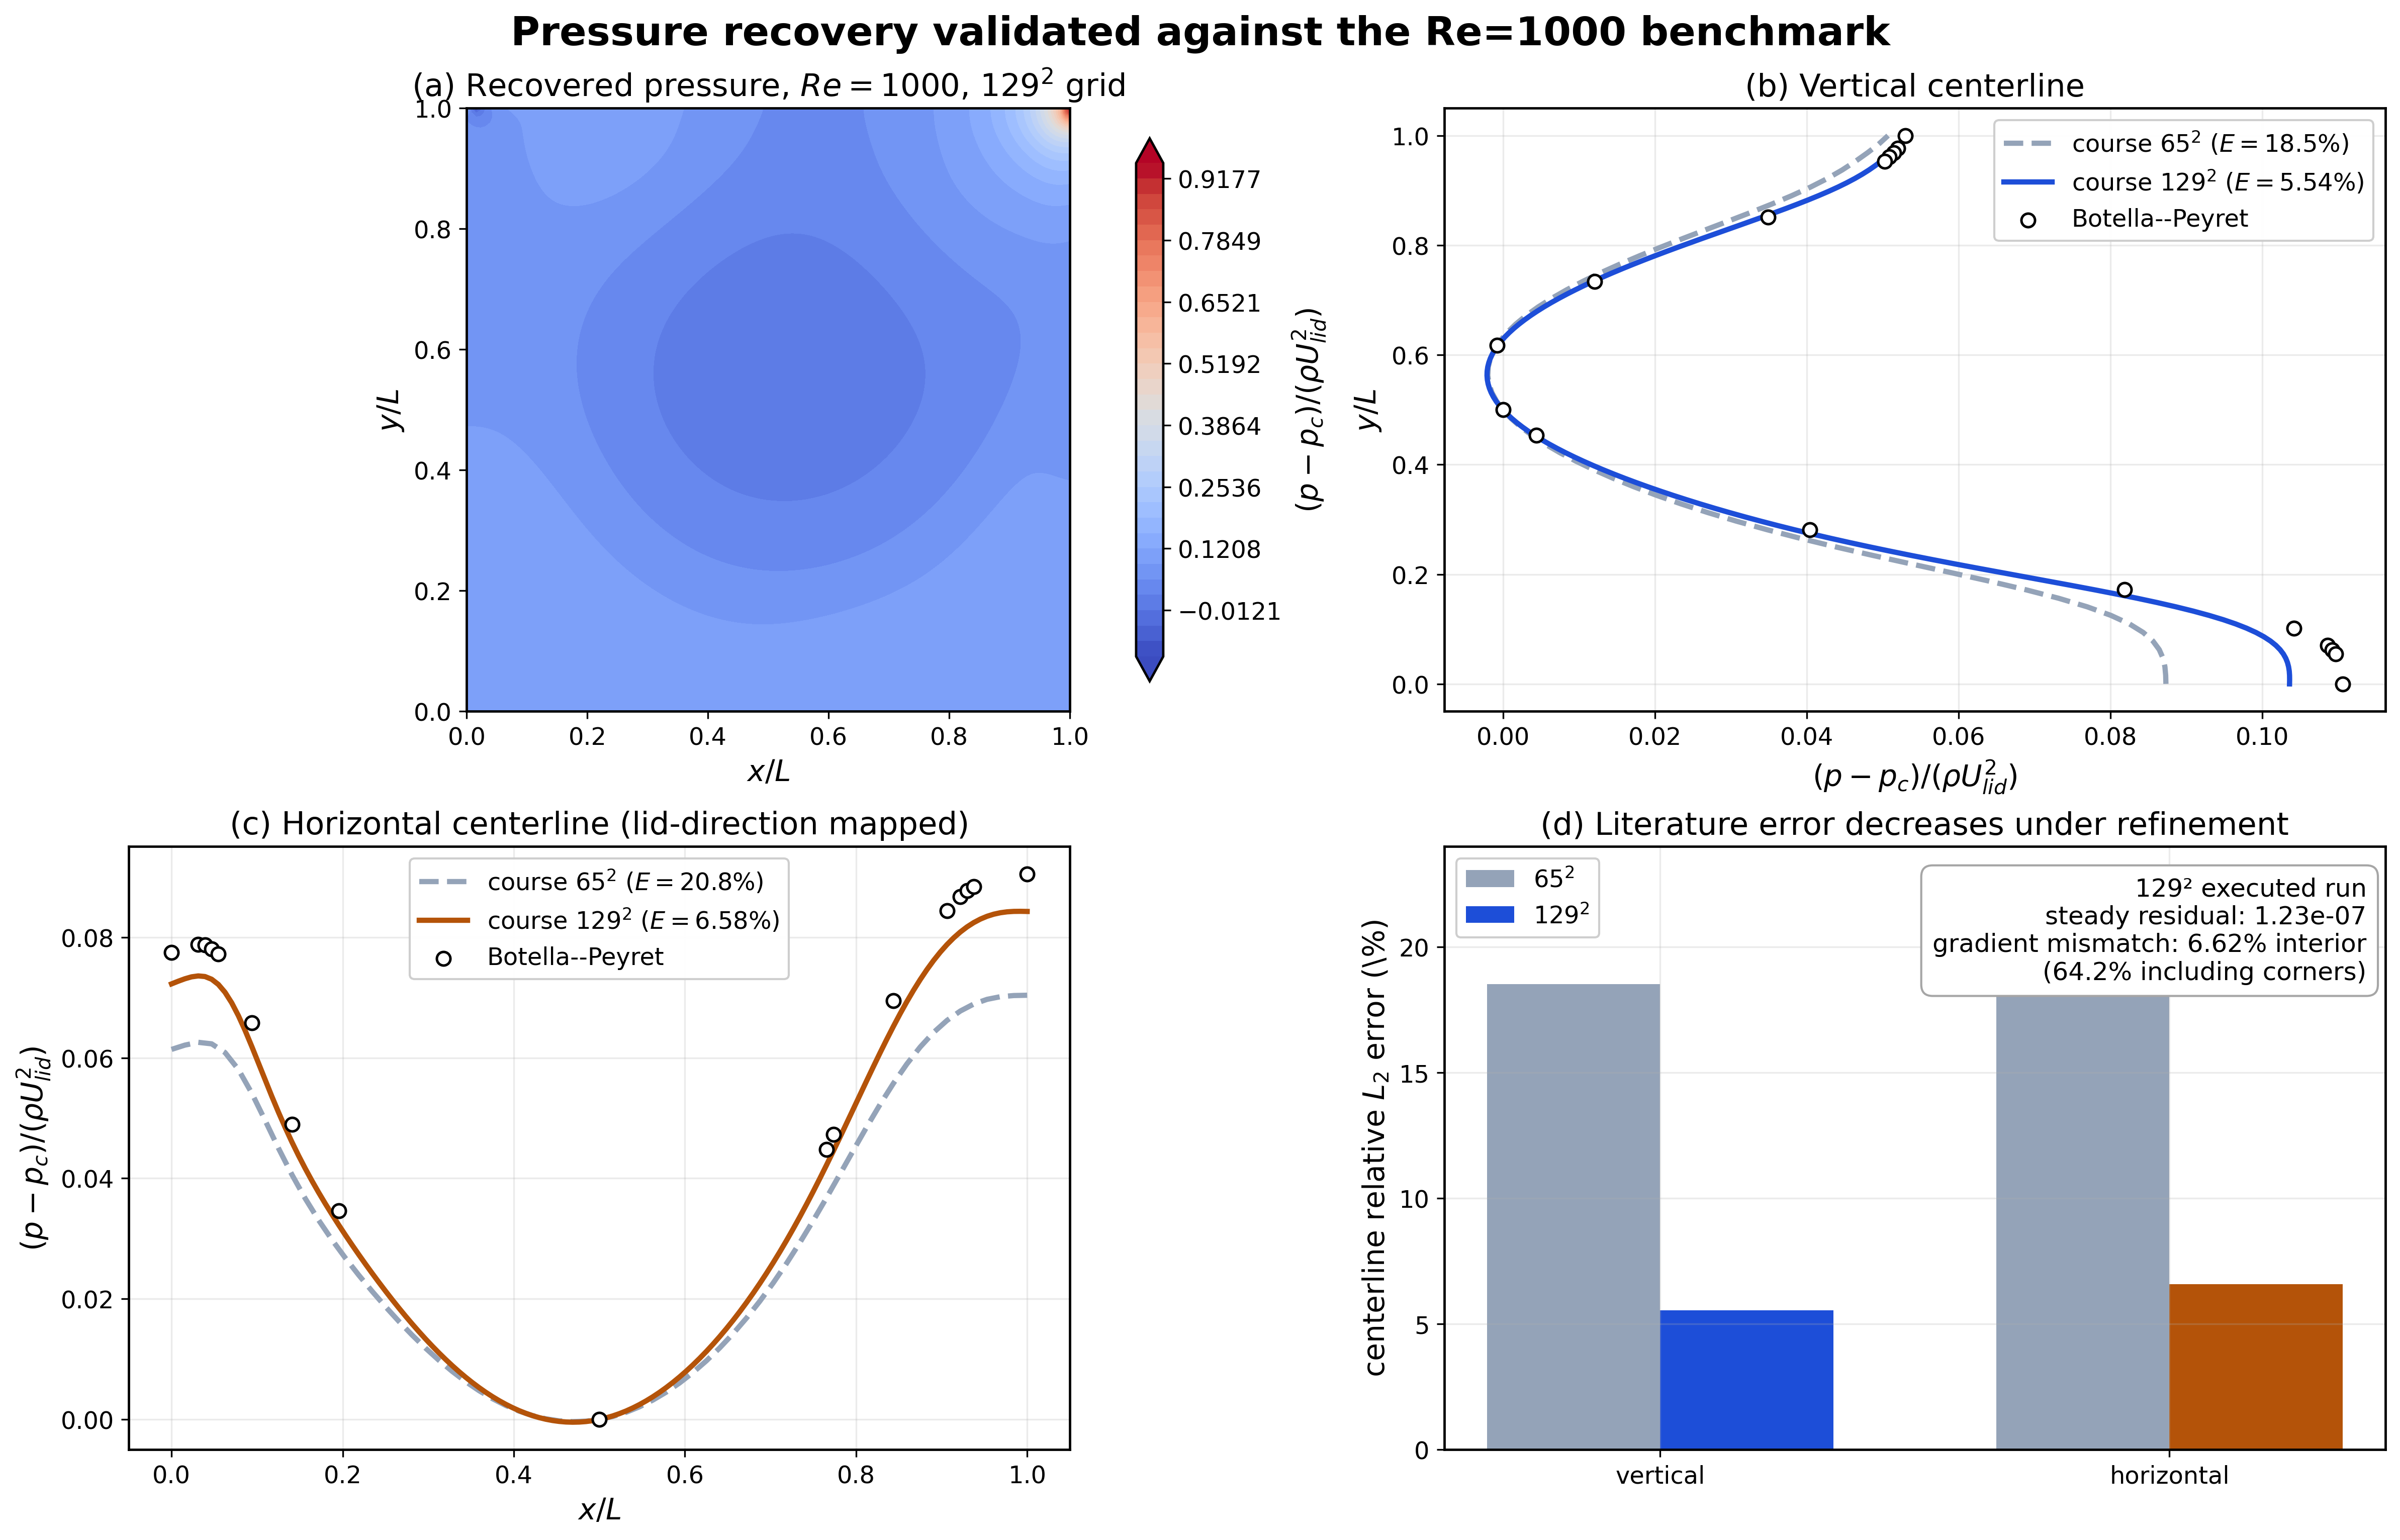

vertical_relative_l2_n65,vertical_relative_l2_n129,horizontal_relative_l2_n65,horizontal_relative_l2_n129,gradient_mismatch_interior,gradient_mismatch_global
0.185167,0.055376,0.207701,0.06575,0.06621,0.641532


Paper-ready files:
 - /workspace/scratch/b22ffb32910d/course_release_v3/MIE690A_AI_in_Fluid_Mechanics/results/article_figures/fig02_cavity_benchmark.pdf
 - /workspace/scratch/b22ffb32910d/course_release_v3/MIE690A_AI_in_Fluid_Mechanics/results/article_figures/fig08_pressure_recovery.pdf


In [2]:
from IPython.display import Image, display
import pandas as pd

velocity_validation = build_ghia_velocity_validation(COURSE_ROOT)
pressure_validation = build_pressure_validation(COURSE_ROOT)

display(Image(filename=str(velocity_validation["figure"]["png"]), width=1050))
display(pd.DataFrame([velocity_validation["metrics"]]))
display(Image(filename=str(pressure_validation["figure"]["png"]), width=1150))
display(pd.DataFrame([pressure_validation["metrics"]]))

print("Paper-ready files:")
print(" -", velocity_validation["figure"]["pdf"])
print(" -", pressure_validation["figure"]["pdf"])


In [3]:
# Optional production recomputation. The default uses the retained, executed runs so
# the notebook opens quickly and deterministically. Set True only when you intend to
# spend several minutes regenerating the two Re=1000 grids.
RECOMPUTE_PRESSURE_RUNS = False

if RECOMPUTE_PRESSURE_RUNS:
    import subprocess
    subprocess.run(
        [sys.executable, str(COURSE_ROOT / "common" / "run_cavity_pressure_validation.py")],
        cwd=COURSE_ROOT,
        check=True,
    )
    pressure_validation = build_pressure_validation(COURSE_ROOT)
    display(Image(filename=str(pressure_validation["figure"]["png"]), width=1150))
else:
    print("Using retained Re=1000 N=65 and N=129 solver outputs; set the switch to rerun them.")


Using retained Re=1000 N=65 and N=129 solver outputs; set the switch to rerun them.


## 1. Physical problem

The lid-driven cavity is a square box filled with an incompressible viscous fluid.

Boundary conditions:

- top wall moves to the right with velocity $U=1$,
- bottom wall is stationary,
- left wall is stationary,
- right wall is stationary,
- no penetration at all walls.

The Reynolds number is

$$
Re=\frac{UL}{\nu}.
$$

Here $U=1$, $L=1$, and $Re=100$.  
Therefore $\nu=1/Re=0.01$.

This is a classical benchmark because it is simple to define but produces a nontrivial recirculating vortex.

## 2. Governing equations in streamfunction-vorticity form

For 2D incompressible flow, define the streamfunction $\psi$:

$$
u = \frac{\partial \psi}{\partial y},
\qquad
v = -\frac{\partial \psi}{\partial x}.
$$

This automatically satisfies incompressibility:

$$
\frac{\partial u}{\partial x}
+
\frac{\partial v}{\partial y}
=0.
$$

Define vorticity:

$$
\omega =
\frac{\partial v}{\partial x}
-
\frac{\partial u}{\partial y}.
$$

The streamfunction and vorticity are related by:

$$
\nabla^2 \psi = -\omega.
$$

The vorticity transport equation is:

$$
\frac{\partial \omega}{\partial t}
+
u\frac{\partial \omega}{\partial x}
+
v\frac{\partial \omega}{\partial y}
=
\frac{1}{Re}\nabla^2\omega.
$$

This notebook solves these equations until the flow becomes approximately steady.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Ghia et al. Re=100 benchmark data
GHIA_Y = np.array([
    1.0000, 0.9766, 0.9688, 0.9609, 0.9531,
    0.8516, 0.7344, 0.6172, 0.5000, 0.4531,
    0.2813, 0.1719, 0.1016, 0.0703, 0.0625,
    0.0547, 0.0000
])

GHIA_U = np.array([
    1.00000, 0.84123, 0.78871, 0.73722, 0.68717,
    0.23151, 0.00332, -0.13641, -0.20581, -0.21090,
    -0.15662, -0.10150, -0.06434, -0.04775, -0.04192,
    -0.03717, 0.00000
])

GHIA_X = np.array([
    1.0000, 0.9688, 0.9609, 0.9531, 0.9453,
    0.9063, 0.8594, 0.8047, 0.5000, 0.2344,
    0.2266, 0.1563, 0.0938, 0.0781, 0.0703,
    0.0625, 0.0000
])

GHIA_V = np.array([
    0.00000, -0.05906, -0.07391, -0.08864, -0.10313,
    -0.16914, -0.22445, -0.24533, 0.05454, 0.17527,
    0.17507, 0.16077, 0.12317, 0.10890, 0.10091,
    0.09233, 0.00000
])

## 3. Build the grid

We use a square grid with $N\times N$ points.

For the required Week-1 run, use:

$$
N=65.
$$

This is not a publication-quality grid. It is a teaching grid:
- small enough to run quickly,
- large enough to compare with Ghia,
- simple enough for students to inspect.

In [ ]:
def build_grid(N):
    x = np.linspace(0.0, 1.0, N)
    y = np.linspace(0.0, 1.0, N)
    X, Y = np.meshgrid(x, y)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    return x, y, X, Y, dx, dy

N = 65
x, y, X, Y, dx, dy = build_grid(N)

print("Grid size:", N, "x", N)
print("dx =", dx)
print("dy =", dy)

## 4. Finite-difference operators

We need:
- first derivatives for convection,
- Laplacian for diffusion,
- Poisson solve for streamfunction.

The Laplacian stencil is the same one learned in the Python notebook.

In [ ]:
def laplacian(phi, dx, dy):
    lap = np.zeros_like(phi)
    lap[1:-1, 1:-1] = (
        (phi[1:-1, 2:] - 2.0*phi[1:-1, 1:-1] + phi[1:-1, :-2]) / dx**2
        + (phi[2:, 1:-1] - 2.0*phi[1:-1, 1:-1] + phi[:-2, 1:-1]) / dy**2
    )
    return lap

## 5. Boundary conditions for vorticity

For the streamfunction, the walls are streamlines. We set:

$$
\psi = 0
$$

on all walls.

The wall vorticity is not directly specified. It is inferred from the no-slip condition using a finite-difference wall formula. For the moving lid, the formula includes the lid velocity $U$.

This is one of the most important parts of the code. If the wall vorticity is wrong, the whole cavity solution becomes wrong.

In [ ]:
def apply_vorticity_boundary_conditions(psi, omega, U, dx, dy):
    # Bottom wall: stationary
    omega[0, 1:-1] = -2.0 * psi[1, 1:-1] / dy**2

    # Top wall: moving lid with u = U
    omega[-1, 1:-1] = -2.0 * psi[-2, 1:-1] / dy**2 - 2.0 * U / dy

    # Left wall: stationary
    omega[1:-1, 0] = -2.0 * psi[1:-1, 1] / dx**2

    # Right wall: stationary
    omega[1:-1, -1] = -2.0 * psi[1:-1, -2] / dx**2

    # Corner values: simple averages of neighboring wall values
    omega[0, 0] = 0.5 * (omega[0, 1] + omega[1, 0])
    omega[0, -1] = 0.5 * (omega[0, -2] + omega[1, -1])
    omega[-1, 0] = 0.5 * (omega[-1, 1] + omega[-2, 0])
    omega[-1, -1] = 0.5 * (omega[-1, -2] + omega[-2, -1])

    return omega

## 6. Solve the streamfunction Poisson equation

At each time step, vorticity $\omega$ is known and we solve:

$$
\nabla^2 \psi = -\omega.
$$

We use Jacobi iterations. This is simple and educational, although not the fastest method.

In [ ]:
def solve_streamfunction_poisson(psi, omega, dx, dy, iterations=60):
    dx2 = dx**2
    dy2 = dy**2
    denom = 2.0 * (dx2 + dy2)

    for _ in range(iterations):
        old = psi.copy()

        psi[1:-1, 1:-1] = (
            (old[1:-1, 2:] + old[1:-1, :-2]) * dy2
            + (old[2:, 1:-1] + old[:-2, 1:-1]) * dx2
            + omega[1:-1, 1:-1] * dx2 * dy2
        ) / denom

        # Streamfunction is zero on the walls
        psi[0, :] = 0.0
        psi[-1, :] = 0.0
        psi[:, 0] = 0.0
        psi[:, -1] = 0.0

    return psi

## 7. Compute velocity from streamfunction

The velocity is computed from:

$$
u = \frac{\partial\psi}{\partial y},
\qquad
v = -\frac{\partial\psi}{\partial x}.
$$

Then the boundary velocities are imposed explicitly:
- top lid: $u=U,\;v=0$,
- other walls: $u=v=0$.

In [ ]:
def compute_velocity(psi, U, dx, dy):
    u = np.zeros_like(psi)
    v = np.zeros_like(psi)

    u[1:-1, 1:-1] = (psi[2:, 1:-1] - psi[:-2, 1:-1]) / (2.0 * dy)
    v[1:-1, 1:-1] = -(psi[1:-1, 2:] - psi[1:-1, :-2]) / (2.0 * dx)

    # Velocity boundary conditions
    u[0, :] = 0.0
    u[-1, :] = U
    u[:, 0] = 0.0
    u[:, -1] = 0.0

    v[0, :] = 0.0
    v[-1, :] = 0.0
    v[:, 0] = 0.0
    v[:, -1] = 0.0

    return u, v

## 8. Advance the vorticity equation

The vorticity equation is

$$
\frac{\partial \omega}{\partial t}
=
-u\frac{\partial \omega}{\partial x}
-v\frac{\partial \omega}{\partial y}
+
\frac{1}{Re}\nabla^2\omega.
$$

The first two terms are convection.  
The last term is viscous diffusion.

This explicit update is written with vectorized NumPy operations.

In [ ]:
def advance_vorticity(omega, u, v, Re, dt, dx, dy):
    old = omega.copy()

    dwdx = (old[1:-1, 2:] - old[1:-1, :-2]) / (2.0 * dx)
    dwdy = (old[2:, 1:-1] - old[:-2, 1:-1]) / (2.0 * dy)

    lap_omega = (
        (old[1:-1, 2:] - 2.0*old[1:-1, 1:-1] + old[1:-1, :-2]) / dx**2
        + (old[2:, 1:-1] - 2.0*old[1:-1, 1:-1] + old[:-2, 1:-1]) / dy**2
    )

    convection = u[1:-1, 1:-1] * dwdx + v[1:-1, 1:-1] * dwdy
    diffusion = (1.0 / Re) * lap_omega

    omega[1:-1, 1:-1] = old[1:-1, 1:-1] + dt * (-convection + diffusion)

    return omega, old

## 9. Run the solver

The residual used here is the relative change in vorticity:

$$
R =
\frac{\|\omega^{n+1}-\omega^n\|_2}
{\|\omega^{n+1}\|_2}.
$$

This is not the only possible residual, but it is easy to understand.  
If the residual decreases, the field is approaching a steady state.

In [ ]:
def run_cavity(Re=100, N=65, dt=0.001, steps=10000, poisson_iters=60, U=1.0, report_every=2000):
    x, y, X, Y, dx, dy = build_grid(N)

    psi = np.zeros((N, N))
    omega = np.zeros((N, N))

    omega = apply_vorticity_boundary_conditions(psi, omega, U, dx, dy)

    residual_steps = []
    residual_values = []

    for step in range(1, steps + 1):
        psi = solve_streamfunction_poisson(psi, omega, dx, dy, iterations=poisson_iters)
        omega = apply_vorticity_boundary_conditions(psi, omega, U, dx, dy)
        u, v = compute_velocity(psi, U, dx, dy)

        omega, old_omega = advance_vorticity(omega, u, v, Re, dt, dx, dy)
        omega = apply_vorticity_boundary_conditions(psi, omega, U, dx, dy)

        if step % report_every == 0:
            residual = np.linalg.norm(omega - old_omega) / (np.linalg.norm(omega) + 1e-30)
            residual_steps.append(step)
            residual_values.append(residual)
            print(f"step {step:6d}: residual = {residual:.3e}")

    # Final streamfunction/velocity update
    psi = solve_streamfunction_poisson(psi, omega, dx, dy, iterations=2*poisson_iters)
    omega = apply_vorticity_boundary_conditions(psi, omega, U, dx, dy)
    u, v = compute_velocity(psi, U, dx, dy)

    return {
        "x": x, "y": y, "X": X, "Y": Y,
        "psi": psi, "omega": omega, "u": u, "v": v,
        "residual_steps": np.array(residual_steps),
        "residual_values": np.array(residual_values),
        "Re": Re, "N": N, "dt": dt, "U": U
    }

result = run_cavity(Re=100, N=65, dt=0.001, steps=10000, poisson_iters=60, report_every=2000)

## 10. Compare with Ghia et al.

Ghia et al. reported:
- $u/U$ along the vertical centerline $x/L=0.5$,
- $v/U$ along the horizontal centerline $y/L=0.5$.

A benchmark comparison should use the same sampling lines.

In [ ]:
def centerline_profiles(result):
    x = result["x"]
    y = result["y"]
    u = result["u"]
    v = result["v"]
    U = result["U"]

    mid = len(x) // 2

    u_center = u[:, mid] / U       # u along x = 0.5
    v_center = v[mid, :] / U       # v along y = 0.5

    return x, y, u_center, v_center

def ghia_errors(result):
    x, y, u_center, v_center = centerline_profiles(result)

    u_interp = np.interp(GHIA_Y, y, u_center)
    v_interp = np.interp(GHIA_X, x, v_center)

    err_u = np.linalg.norm(u_interp - GHIA_U) / np.linalg.norm(GHIA_U)
    err_v = np.linalg.norm(v_interp - GHIA_V) / np.linalg.norm(GHIA_V)

    return err_u, err_v

err_u, err_v = ghia_errors(result)

print(f"Relative L2 error for u/U centerline = {err_u:.4f}")
print(f"Relative L2 error for v/U centerline = {err_v:.4f}")

In [ ]:
x, y, u_center, v_center = centerline_profiles(result)

plt.figure(figsize=(5, 4))
plt.plot(u_center, y, label="finite difference")
plt.scatter(GHIA_U, GHIA_Y, s=25, label="Ghia et al.")
plt.xlabel(r"$u/U$ at $x/L=0.5$")
plt.ylabel(r"$y/L$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.plot(x, v_center, label="finite difference")
plt.scatter(GHIA_X, GHIA_V, s=25, label="Ghia et al.")
plt.xlabel(r"$x/L$")
plt.ylabel(r"$v/U$ at $y/L=0.5$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(5, 4))
plt.semilogy(result["residual_steps"], result["residual_values"], "o-")
plt.xlabel("time step")
plt.ylabel("relative vorticity-change residual")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(5, 4))
speed = np.sqrt(result["u"]**2 + result["v"]**2)
plt.contourf(result["X"], result["Y"], speed, levels=40)
plt.colorbar(label="speed")
plt.streamplot(result["X"], result["Y"], result["u"], result["v"], density=1.3, linewidth=0.6)
plt.xlabel("x/L")
plt.ylabel("y/L")
plt.title("Lid-driven cavity streamlines, Re=100")
plt.tight_layout()
plt.show()

## 11. What students should learn from this solver

This solver is not meant to be the fastest cavity solver. It is meant to teach the structure of CFD:

1. The physical problem defines boundary conditions.
2. The PDE is rewritten in a numerically convenient form.
3. The domain is discretized on a grid.
4. Derivatives are approximated by finite differences.
5. Boundary conditions are applied carefully.
6. The solution is advanced or iterated.
7. A residual monitors convergence.
8. The final result is compared with benchmark data.

This is the foundation for AI in fluids. Later, the CFD solution can become:
- training data,
- validation data,
- input to a neural operator,
- a target for a surrogate model,
- a physics-informed residual test.

## 12. Required student deliverables

For this CFD assignment, submit:

1. A plot of $u/U$ along $x/L=0.5$ compared with Ghia.
2. A plot of $v/U$ along $y/L=0.5$ compared with Ghia.
3. A streamplot of the cavity flow.
4. The residual history.
5. The final relative errors $E_u$ and $E_v$.
6. A short explanation of the role of the streamfunction.
7. A short explanation of why wall vorticity boundary conditions matter.
8. A short paragraph explaining how this CFD dataset could later be used for machine learning.

Do not just submit screenshots. Explain what the code is doing.

## Article-output contract

<!-- MIE690A article-aligned validation v3 -->

**Role:** Figures 2 and 8: Ghia velocity centerlines and Botella--Peyret pressure validation.

All manuscript-facing figures must be generated from retained numerical/model outputs through the documented notebook or shared helper, saved under `results/`, and accompanied by machine-readable metrics. Do not redraw curves by eye or substitute a screenshot for a solver-to-reference comparison. The complete ownership table and exact output filenames are in [`ARTICLE_FIGURE_MAP.md`](../../ARTICLE_FIGURE_MAP.md).
